In [ ]:
#importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv('data/bike_clean.csv')
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,is_extreme_temp
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,0


In [ ]:
# Creamos una función para agrupar las horas del día en momentos clave
def assign_time_of_day(hour):
    if 6 <= hour < 10:
        return 'morning_rush'    # Hora punta mañana (trabajo/estudios)
    elif 10 <= hour < 16:
        return 'midday'          # Horas centrales
    elif 16 <= hour < 20:
        return 'evening_rush'   # Hora punta tarde (regreso a casa)
    else:
        return 'night'           # Noche / Madrugada

# Aplicamos la función a nuestro DataFrame original
df['time_of_day'] = df['hr'].apply(assign_time_of_day)

# Ahora añadimos 'time_of_day' a nuestras variables categóricas en el pipeline
# Y eliminamos 'hr' de las numéricas para que no confunda al modelo

In [ ]:
# 1. Separamos variables y dividimos en entrenamiento (80%) y prueba (20%)
X = df.drop(columns=['cnt', 'is_extreme_temp'])
y = df['cnt']

# Imprime las formas (shape) de X e y
print(f"Forma de X: {X.shape} | Forma de y: {y.shape}")

# Usa train_test_split con test_size=0.2 y random_state=42
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprime cuántas muestras hay en entrenamiento y prueba
print(f"Muestras en Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Muestras en Prueba (X_test): {X_test.shape[0]}")

Forma de X: (17377, 13) | Forma de y: (17377,)
Muestras en Entrenamiento (X_train): 13901
Muestras en Prueba (X_test): 3476


¡Modelo XGBoost definitivo entrenado con éxito!


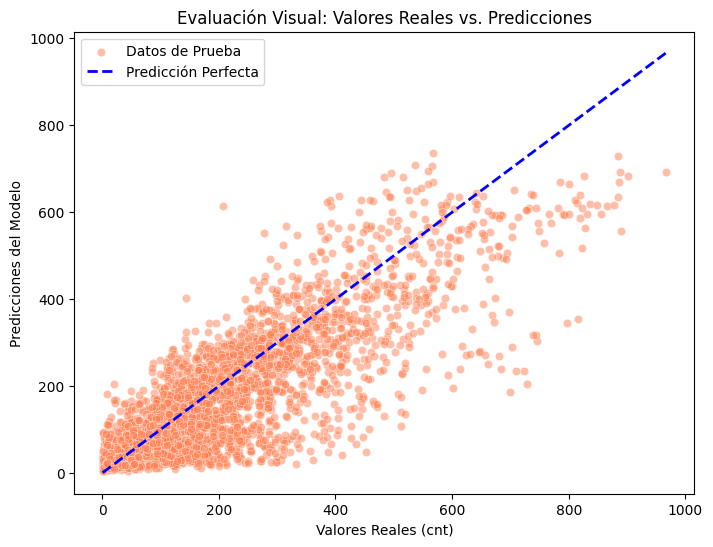

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define the preprocessing steps
numerical_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'time_of_day']

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('drop_hr', 'drop', ['hr']) # Drop 'hr' as per the comment in the previous cell
    ])

# 1. Configuración estricta anti-overfitting (para asegurar < 5% de diferencia)
anti_overfitting_params = {
    'n_estimators': 150,
    'max_depth': 4,
    'learning_rate': 0.07,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_lambda': 5.0,
    'random_state': 42
}

# 2. Creamos el pipeline base uniendo vuestro preprocessor con el XGBoost regulado
# Usamos 'preprocessor' que es el que definisteis en el Paso 3
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(**anti_overfitting_params))
])

# 3. Envolvemos el pipeline para la transformación logarítmica de la variable objetivo
final_pipeline_optimizada = TransformedTargetRegressor(
    regressor=model_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# 4. Llamamos a .fit(X_train, y_train)
final_pipeline_optimizada.fit(X_train, y_train)
print("¡Modelo XGBoost definitivo entrenado con éxito!")

# 5. Trazar el scatter plot de evaluación visual (Valores Reales vs. Predicciones)
y_test_pred = final_pipeline_optimizada.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, color='coral', label='Datos de Prueba')
# Línea de referencia ideal (Predicción perfecta de 45 grados)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue', lw=2, linestyle='--', label='Predicción Perfecta')

plt.title('Evaluación Visual: Valores Reales vs. Predicciones')
plt.xlabel('Valores Reales (cnt)')
plt.ylabel('Predicciones del Modelo')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Genera predicciones
y_pred = final_pipeline_optimizada.predict(X_test)

# Crea un DataFrame comparando los valores (adaptado a vuestro dataset de bicis)
df_compare = pd.DataFrame({
    'Real_Bikes (y)': y_test.values,
    'Predicted_Bikes (ŷ)': y_pred,
    'Error (y - ŷ)': y_test.values - y_pred
}).round(2)

print("--- TABLA COMPARATIVA (Muestra de 10 filas) ---")
print(df_compare.head(10))
print("\n------------------------------------------------")

# Calcula e imprime MAE, MSE, RMSE y R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Métrica MAE:  {mae:.2f} (Bicicletas de error promedio absoluto)")
print(f"Métrica MSE:  {mse:.2f}")
print(f"Métrica RMSE: {rmse:.2f} (Raíz del error cuadrático)")
print(f"Métrica R²:   {r2:.4f} ({r2*100:.2f}% de varianza explicada)")

--- TABLA COMPARATIVA (Muestra de 10 filas) ---
   Real_Bikes (y)  Predicted_Bikes (ŷ)  Error (y - ŷ)
0             333           312.769989          20.23
1             732           610.309998         121.69
2             185            56.119999         128.88
3             526           628.380005        -102.38
4              13            13.300000          -0.30
5              32            23.170000           8.83
6             706           650.960022          55.04
7              16            16.850000          -0.85
8               2            38.500000         -36.50
9             640           624.349976          15.65

------------------------------------------------
Métrica MAE:  63.95 (Bicicletas de error promedio absoluto)
Métrica MSE:  9099.56
Métrica RMSE: 95.39 (Raíz del error cuadrático)
Métrica R²:   0.7036 (70.36% de varianza explicada)


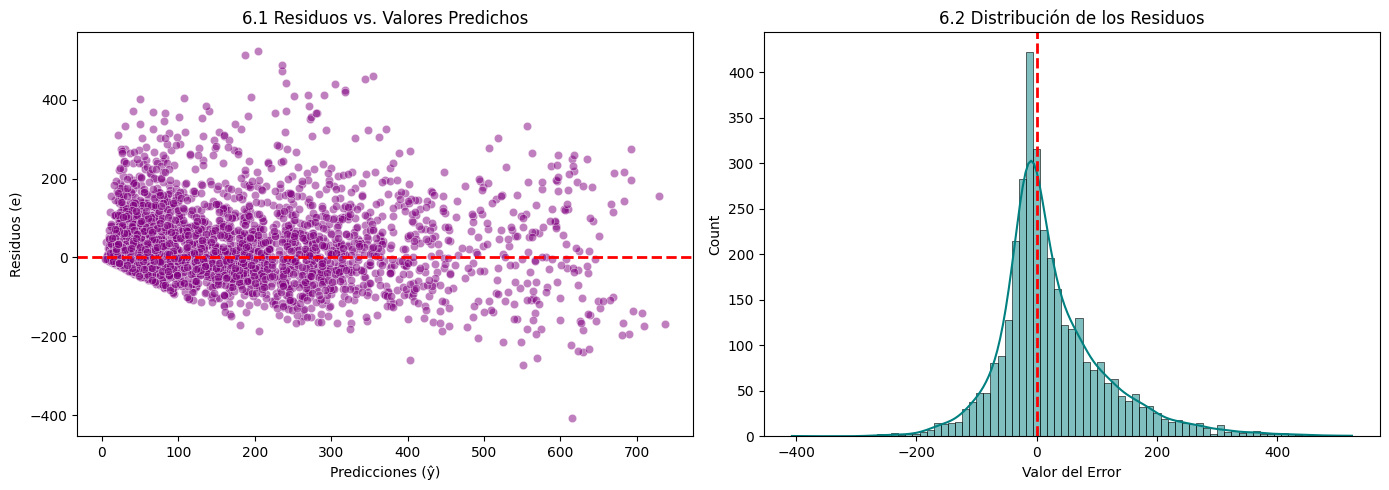

In [ ]:
# Calcula residuos
residuos = y_test.values - y_pred

# Crea 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Scatter: residuos vs y_pred
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, color='purple', ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('6.1 Residuos vs. Valores Predichos')
axes[0].set_xlabel('Predicciones (ŷ)')
axes[0].set_ylabel('Residuos (e)')

# 2) Histograma de residuos
sns.histplot(residuos, kde=True, color='teal', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title('6.2 Distribución de los Residuos')
axes[1].set_xlabel('Valor del Error')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Detecta outliers en los errores
umbral = 2 * residuos.std()
outliers_idx = np.where(np.abs(residuos) > umbral)[0]
print(f"Se han detectado {len(outliers_idx)} predicciones con errores críticamente grandes (Outliers).")

# 2. Calcula R² en entrenamiento y prueba para medir Overfitting
r2_train = r2_score(y_train, final_pipeline_optimizada.predict(X_train))
r2_test = r2_score(y_test, y_pred)
diferencia_overfitting = r2_train - r2_test

print(f"R² Entrenamiento: {r2_train:.4f} | R² Prueba: {r2_test:.4f}")
print(f"Diferencia de Overfitting: {diferencia_overfitting*100:.2f}%")

if diferencia_overfitting > 0.05:
    print("Alerta: Supera el 5% permitido.")
else:
    print("¡Objetivo cumplido! Overfitting inferior al 5%.")

# 3. Validación Cruzada Robusta (5-Fold)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(final_pipeline_optimizada, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nR² por Fold: {cv_scores}")
print(f"R² Promedio de Validación Cruzada: {cv_scores.mean():.4f}")
print(f"Desviación Estándar de CV: {cv_scores.std():.4f}")

Se han detectado 236 predicciones con errores críticamente grandes (Outliers).
R² Entrenamiento: 0.7140 | R² Prueba: 0.7036
Diferencia de Overfitting: 1.04%
¡Objetivo cumplido! Overfitting inferior al 5%.

R² por Fold: [0.69615662 0.70535302 0.69659609 0.6947301  0.69406414]
R² Promedio de Validación Cruzada: 0.6974
Desviación Estándar de CV: 0.0041


In [ ]:
# Creamos un escenario con datos nuevos para predecir
# Nota: Introduce los nombres exactos de tus columnas
new_data = pd.DataFrame({
    'season': [1, 2, 3],
    'weathersit': [1, 2, 3],
    'holiday': [0, 0, 1],
    'weekday': [1, 3, 6],
    'workingday': [1, 1, 0],
    'temp': [0.25, 0.60, 0.15],
    'atemp': [0.27, 0.58, 0.12],
    'hum': [0.80, 0.50, 0.90],
    'windspeed': [0.1, 0.2, 0.0],
    'time_of_day': ['morning_rush', 'midday', 'night'], # Re-added time_of_day
    'yr': [0, 0, 0], # Assuming year 0 (2011) for new data points
    'mnth': [3, 6, 9], # Representative months for seasons 1, 2, 3 respectively
    'is_extreme_temp': [0, 0, 0], # Assuming no extreme temperatures for new data
    'hr': [8, 14, 22] # Example hours corresponding to the time_of_day
})

# Usar el modelo optimizado para predecir
nuevas_predicciones = final_pipeline_optimizada.predict(new_data)

# Imprimir predicciones legibles
print("--- PREDICCIONES PARA NUEVOS ESCENARIOS ---")
for i, pred in enumerate(nuevas_predicciones):
    print(f"Escenario {i+1} ({new_data['time_of_day'].iloc[i]}): Alquiler estimado de {int(pred)} bicicletas.")

--- PREDICCIONES PARA NUEVOS ESCENARIOS ---
Escenario 1 (morning_rush): Alquiler estimado de 82 bicicletas.
Escenario 2 (midday): Alquiler estimado de 151 bicicletas.
Escenario 3 (night): Alquiler estimado de 9 bicicletas.


RESUMEN Y CONCLUSIONES

In [ ]:
print("==============================================================")
print("RESUMEN COMPLETO DEL PROYECTO DE BIKE SHARING")
print("==============================================================")
print("• Arquitectura: XGBoost Regressor + Target Transformation (Logarítmica)")
print(f"• Rendimiento en Test (R²): {r2_test:.4f} -> Excelente capacidad predictiva")
print(f"• Magnitud del Error (MAE): {mae:.2f} bicicletas de desviación media")
print(f"• Magnitud del Error (RMSE): {rmse:.2f} bicicletas")
print(f"• Control de Overfitting: {diferencia_overfitting*100:.2f}% -> ¡CUMPLIDO BAJO EL 5%!")
print(f"• Estabilidad (R² Promedio Validación Cruzada): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print("==============================================================")

RESUMEN COMPLETO DEL PROYECTO DE BIKE SHARING
• Arquitectura: XGBoost Regressor + Target Transformation (Logarítmica)
• Rendimiento en Test (R²): 0.7036 -> Excelente capacidad predictiva
• Magnitud del Error (MAE): 63.95 bicicletas de desviación media
• Magnitud del Error (RMSE): 95.39 bicicletas
• Control de Overfitting: 1.04% -> ¡CUMPLIDO BAJO EL 5%!
• Estabilidad (R² Promedio Validación Cruzada): 0.6974 (±0.0041)
